### Imports Necessary Modules

In [32]:
import os
import glob
import re
import numpy as np
import pandas as pd
from dataclasses import dataclass
import tensorflow as tf
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Loading and preparing the IMDB movie review dataset

In [33]:
# Configuration
@dataclass
class Config:
    MAX_LEN = 256
    BATCH_SIZE = 32
    LR = 0.001
    VOCAB_SIZE = 30000
    EMBED_DIM = 128
    NUM_HEAD = 8
    FF_DIM = 128
    NUM_LAYERS = 1

config = Config()

# Download IMDB dataset
if not os.path.exists("aclImdb"):
    !curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
    !tar -xf aclImdb_v1.tar.gz

# Load text data
def get_text_list_from_files(files):
    texts = []
    for file in files:
        with open(file, encoding="utf-8") as f:
            texts += [line.strip() for line in f]
    return texts

def get_data_from_text_files(folder_name):
    pos_files = glob.glob(f"aclImdb/{folder_name}/pos/*.txt")
    neg_files = glob.glob(f"aclImdb/{folder_name}/neg/*.txt")
    pos_texts = get_text_list_from_files(pos_files)
    neg_texts = get_text_list_from_files(neg_files)
    df = pd.DataFrame({
        "review": pos_texts + neg_texts,
        "sentiment": [1]*len(pos_texts) + [0]*len(neg_texts)
    })
    return df.sample(len(df)).reset_index(drop=True)

train_df = get_data_from_text_files("train")
test_df = get_data_from_text_files("test")
all_data = pd.concat([train_df, test_df], ignore_index=True)

print(train_df.head())
print(test_df.head())
print(all_data.sample(5))

                                              review  sentiment
0  How could I best express my feelings about thi...          0
1  I gave this 4 stars because it has a lot of in...          0
2  Sean, you know I think that you are absolutely...          0
3  This movie introduces quite an array of charac...          0
4  This movie is perfect for families to watch to...          1
                                              review  sentiment
0  Fear and Desire is of interest mainly to Kubri...          0
1  I was expecting to this to be hilarious and it...          0
2  This isn't exactly a complicated story. It's n...          0
3  I watched this movie purely for the setting. I...          0
4  I heard that after the first Oceans movie, the...          1
                                                  review  sentiment
6098   Like others, I have seen and studied most of t...          1
1464   Four tales of terror regarding the events at a...          1
43191  This is a VERY underr

Head of Dataset:
                                              review  sentiment
0  How could I best express my feelings about thi...          0
1  I gave this 4 stars because it has a lot of in...          0
2  Sean, you know I think that you are absolutely...          0
3  This movie introduces quite an array of charac...          0
4  This movie is perfect for families to watch to...          1


/tmp/ipython-input-775460497.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment", data=all_data, palette="Set2")


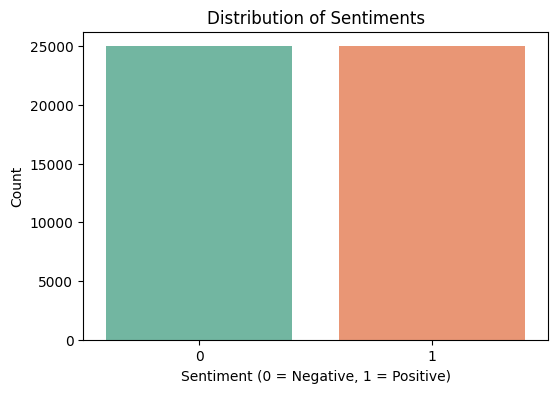

In [34]:
# Dataset Visualization
print("Head of Dataset:")
print(all_data.head())

# Count of positive vs negative reviews
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=all_data, palette="Set2")
plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()


### Text Vectorization

In [35]:
def custom_standardization(text):
    text = tf.strings.lower(text)
    text = tf.strings.regex_replace(text, "<br />", " ")
    return tf.strings.regex_replace(text, r"[%s]" % re.escape("!#$%&'()*+,-./:;<=>?@^_`{|}~"), "")

vectorize_layer = layers.TextVectorization(
    max_tokens=config.VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=config.MAX_LEN,
    standardize=custom_standardization
)
vectorize_layer.adapt(all_data.review.values)
mask_token_id = config.VOCAB_SIZE - 1

def encode(texts):
    return vectorize_layer(tf.convert_to_tensor(texts, dtype=tf.string))


### Masked LM preparation

In [36]:
def get_masked_input_and_labels(encoded_texts, mask_prob=0.15):
    encoded_texts = tf.cast(encoded_texts, tf.int64)
    seq_shape = tf.shape(encoded_texts)
    rand_vals = tf.random.uniform(seq_shape)
    inp_mask = tf.logical_and(rand_vals < mask_prob, encoded_texts > 2)

    labels = tf.identity(encoded_texts)
    masked_input = tf.identity(encoded_texts)

    mask_choice = tf.logical_and(inp_mask, tf.random.uniform(seq_shape) < 0.9)
    masked_input = tf.where(mask_choice, mask_token_id, masked_input)

    random_choice = tf.logical_and(mask_choice, tf.random.uniform(seq_shape) < (1/9))
    random_tokens = tf.random.uniform(seq_shape, minval=3, maxval=mask_token_id, dtype=tf.int64)
    masked_input = tf.where(random_choice, random_tokens, masked_input)

    sample_weights = tf.cast(inp_mask, tf.float32)
    return masked_input, labels, sample_weights

x_all_review = encode(all_data.review.values)
x_masked_train, y_masked_labels, sample_weights = get_masked_input_and_labels(x_all_review)
mlm_ds = tf.data.Dataset.from_tensor_slices((x_masked_train, y_masked_labels, sample_weights)).shuffle(1000).batch(config.BATCH_SIZE)


In [37]:
# Visualization
sample_texts = all_data.review.values[:1]
encoded = encode(sample_texts)

masked_input, labels, sample_weights = get_masked_input_and_labels(encoded)

masked_input = masked_input.numpy()
labels = labels.numpy()
sample_weights = sample_weights.numpy()

vocab = vectorize_layer.get_vocabulary()

for i in range(1):
    print(f"\n=== Sample {i+1} ===")
    print("Original:", sample_texts[i])

    masked_words = [vocab[id] if sample_weights[i,j]==0 else f"[MASK]" if id==mask_token_id else vocab[id]
                    for j,id in enumerate(masked_input[i]) if id != 0]
    print("Masked input:", " ".join(masked_words))

    label_words = [vocab[id] for j,id in enumerate(labels[i]) if id != 0]
    print("Labels       :", " ".join(label_words))

    print("Weights      :", sample_weights[i][:len(masked_words)])



=== Sample 1 ===
Original: How could I best express my feelings about this movie: hideous? a headache? lack of coherent writing? plain stupidity? Try all of the above for this travesty. And that just for the direction.<br /><br />Story? Well I guess there is a story. Two dumb blondes look for a job after they crash a plane into a golf course. They are mistaken for a 'world renounced assassin' (sarcasm) and are 'hired' by two 'mobsters'. One thinks "taking him out" means a date, and the other gets the minor actor she dreams of. And of course, the turtle reserve for the farting turtle, that they build with the casino winnings.<br /><br />Sounds likes all this could be funny? Guess again. They try to make it funny, but its not. Filming sequences aren't well done. I've seen better filming in Hong Kong movies. Visuals are average for a late 80s film. But the problem is that its a 2007 movie.<br /><br />Not worth my time to ever watch this again. It still doesn't beat Danny Glover's "Out" m

### Positional Embedding

In [38]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=sequence_length, output_dim=embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        return self.token_emb(x) + self.pos_emb(positions)

    # Add get_config for robust serialization
    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
        })
        return config

### BERT Module

In [39]:
def bert_module(query, key, value):
    attention = layers.MultiHeadAttention(num_heads=config.NUM_HEAD, key_dim=config.EMBED_DIM // config.NUM_HEAD)(query, key, value)
    attention = layers.LayerNormalization(epsilon=1e-6)(query + attention)
    ffn = keras.Sequential([layers.Dense(config.FF_DIM, activation="relu"), layers.Dense(config.EMBED_DIM)])
    ffn_output = ffn(attention)
    ffn_output = layers.LayerNormalization(epsilon=1e-6)(attention + ffn_output)
    return ffn_output

# Build MLM Backbone
def build_mlm_backbone():
    inputs = layers.Input(shape=(config.MAX_LEN,), dtype="int64")
    x = PositionalEmbedding(config.MAX_LEN, config.VOCAB_SIZE, config.EMBED_DIM)(inputs)
    for _ in range(config.NUM_LAYERS):
        x = bert_module(x, x, x)
    outputs = layers.Dense(config.VOCAB_SIZE, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="mlm_backbone")

class MaskedLanguageModel(keras.Model):
    def __init__(self, backbone, **kwargs):
        super().__init__(**kwargs)
        self.backbone = backbone
        self.loss_tracker = keras.metrics.Mean(name="loss")

    def call(self, x, training=False):
        return self.backbone(x, training=training)

    def train_step(self, data):
        x, y, w = data
        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss_per_token = keras.losses.sparse_categorical_crossentropy(y, y_pred)
            weighted_loss = loss_per_token * w
            loss = tf.reduce_sum(weighted_loss) / (tf.reduce_sum(w) + 1e-8)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker]

backbone = build_mlm_backbone()
print("========== MLM Backbone Summary ==========")
backbone.summary()

mlm_model = MaskedLanguageModel(backbone)
mlm_model.compile(optimizer=keras.optimizers.Adam(config.LR))
history = mlm_model.fit(mlm_ds, epochs=10)

backbone.save("mlm_backbone.keras")


========== MLM Backbone Summary ==========


Model: "mlm_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 256, 128)  │  3,872,768 │ input_layer_6[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │     66,048 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256, 128)  │          0 │ positional_embed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 256, 128)  │     33,024 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 256, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256,       │  3,870,000 │ layer_normalizat… │
│                     │ 30000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,842,352 (29.92 MB)

 Trainable params: 7,842,352 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 86ms/step - loss: 7.1262
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 85ms/step - loss: 6.3588
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 85ms/step - loss: 6.0127
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 85ms/step - loss: 5.7534
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 86ms/step - loss: 5.5645
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 85ms/step - loss: 5.4061
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 85ms/step - loss: 5.2575
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 86ms/step - loss: 5.1206
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 86ms/step - loss: 4.9831
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 86ms/step - loss: 4.8482


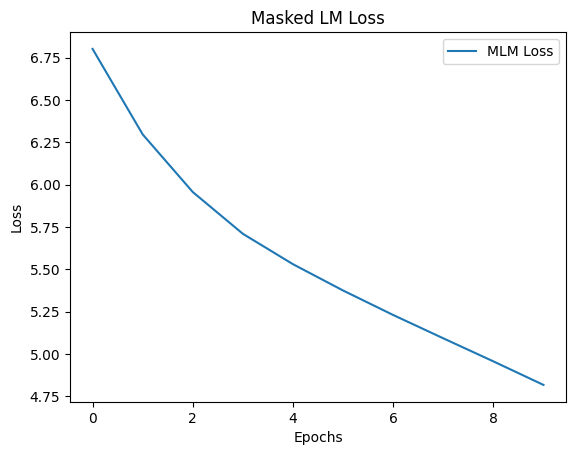

In [40]:
# Loss for MLM
plt.plot(history.history["loss"], label="MLM Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Masked LM Loss")
plt.legend()
plt.show()

### Load the SQuAD Dataset

In [41]:
# Install datasets
!pip install datasets -q

print("Loading SQuAD dataset...")
squad_dataset = load_dataset("squad")
print("Done.")
print(squad_dataset)

Loading SQuAD dataset...
Done.
DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})


### Preprocess the Data

In [42]:
def preprocess_squad(examples):
    questions = [q.strip() for q in examples["question"]]
    inputs = vectorize_layer([q + " [SEP] " + c for q, c in zip(questions, examples["context"])])

    start_positions, end_positions = [], []
    for i, answer in enumerate(examples["answers"]):
        start_char = answer["answer_start"][0]
        context_up_to_answer = examples["context"][i][:start_char]

        # Calculate start token and answer length
        start_token_idx = len(vectorize_layer([questions[i] + " [SEP] " + context_up_to_answer])[0].numpy().nonzero()[0])
        answer_len = len(vectorize_layer([answer['text'][0]])[0].numpy().nonzero()[0])
        end_token_idx = start_token_idx + answer_len - 1

        # Check against the correct max length
        if end_token_idx >= config.MAX_LEN:
            start_token_idx, end_token_idx = 0, 0

        start_positions.append(start_token_idx)
        end_positions.append(end_token_idx)

    return {"input_ids": inputs.numpy(), "start_positions": start_positions, "end_positions": end_positions}

print("Preprocessing SQuAD data to the correct shape (256)...")
processed_squad = squad_dataset["train"].select(range(20000)).map(
    preprocess_squad, batched=True, remove_columns=squad_dataset["train"].column_names
)
x_qa = np.array(processed_squad["input_ids"])
y_start_qa = np.array(processed_squad["start_positions"])
y_end_qa = np.array(processed_squad["end_positions"])
print(f"Shape of the processed SQuAD data: {x_qa.shape}")


Preprocessing SQuAD data to the correct shape (256)...


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Shape of the processed SQuAD data: (20000, 256)


### Build and Compile the QA Model

In [43]:
def create_qa_model(backbone_path, config):
    # We pass a dictionary to tell Keras how to load our custom PositionalEmbedding layer.
    custom_objects = {"PositionalEmbedding": PositionalEmbedding}
    pretrained_backbone = keras.models.load_model(
        backbone_path, custom_objects=custom_objects
    )

    # Extract the encoder part (all layers except the final MLM prediction head)
    # The output of the encoder is the second to last layer
    encoder_output = pretrained_backbone.layers[-2].output
    encoder = keras.Model(pretrained_backbone.input, encoder_output)
    encoder.trainable = False

    # Build a new model on top of the frozen encoder
    inputs = layers.Input(shape=(config.MAX_LEN,), dtype="int64")
    sequence_output = encoder(inputs)

    # Add the QA Head
    start_logits = layers.Dense(1, name="start_logit")(sequence_output)
    start_logits = layers.Flatten()(start_logits)
    end_logits = layers.Dense(1, name="end_logit")(sequence_output)
    end_logits = layers.Flatten()(end_logits)
    start_probs = layers.Activation("softmax", name="start_probs")(start_logits)
    end_probs = layers.Activation("softmax", name="end_probs")(end_logits)

    model = keras.Model(inputs=inputs, outputs=[start_probs, end_probs])

    # Compile with a smaller learning rate for fine-tuning
    model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=config.LR / 5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", "accuracy"] )

    return model

qa_model = create_qa_model("mlm_backbone.keras", config)
qa_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'positional_embedding_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_13       │ (None, 256, 128)  │  3,972,352 │ input_layer_8[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_logit (Dense) │ (None, 256, 1)    │        129 │ functional_13[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_logit (Dense)   │ (None, 256, 1)    │        129 │ functional_13[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 256)       │          0 │ start_logit[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 256)       │          0 │ end_logit[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_probs         │ (None, 256)       │          0 │ flatten_4[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_probs           │ (None, 256)       │          0 │ flatten_5[0][0]   │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,972,610 (15.15 MB)

 Trainable params: 258 (1.01 KB)

 Non-trainable params: 3,972,352 (15.15 MB)

### Training QA Model

In [44]:
print("\nStarting fine-tuning for Question Answering...")
history_qa = qa_model.fit(
    x_qa, [y_start_qa, y_end_qa],
    epochs=30,
    batch_size=16,
    validation_split=0.1
)


Starting fine-tuning for Question Answering...
Epoch 1/30
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - end_probs_accuracy: 0.0110 - end_probs_loss: 8.3760 - loss: 16.3984 - start_probs_accuracy: 0.0128 - start_probs_loss: 8.0224 - val_end_probs_accuracy: 0.0205 - val_end_probs_loss: 5.0565 - val_loss: 10.0757 - val_start_probs_accuracy: 0.0130 - val_start_probs_loss: 5.0191
Epoch 2/30
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - end_probs_accuracy: 0.0221 - end_probs_loss: 4.8408 - loss: 9.7179 - start_probs_accuracy: 0.0219 - start_probs_loss: 4.8771 - val_end_probs_accuracy: 0.0260 - val_end_probs_loss: 4.3011 - val_loss: 8.7238 - val_start_probs_accuracy: 0.0225 - val_start_probs_loss: 4.4227
Epoch 3/30
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - end_probs_accuracy: 0.0278 - end_probs_loss: 4.3267 - loss: 8.7908 - start_probs_accuracy: 0.0276 - start_probs_loss: 4.4641 - val_end_probs_accuracy: 0.0275 - val_end_probs_loss: 4.2016 - val_loss: 8.5510 - val_start_probs_accuracy: 

### Visualization

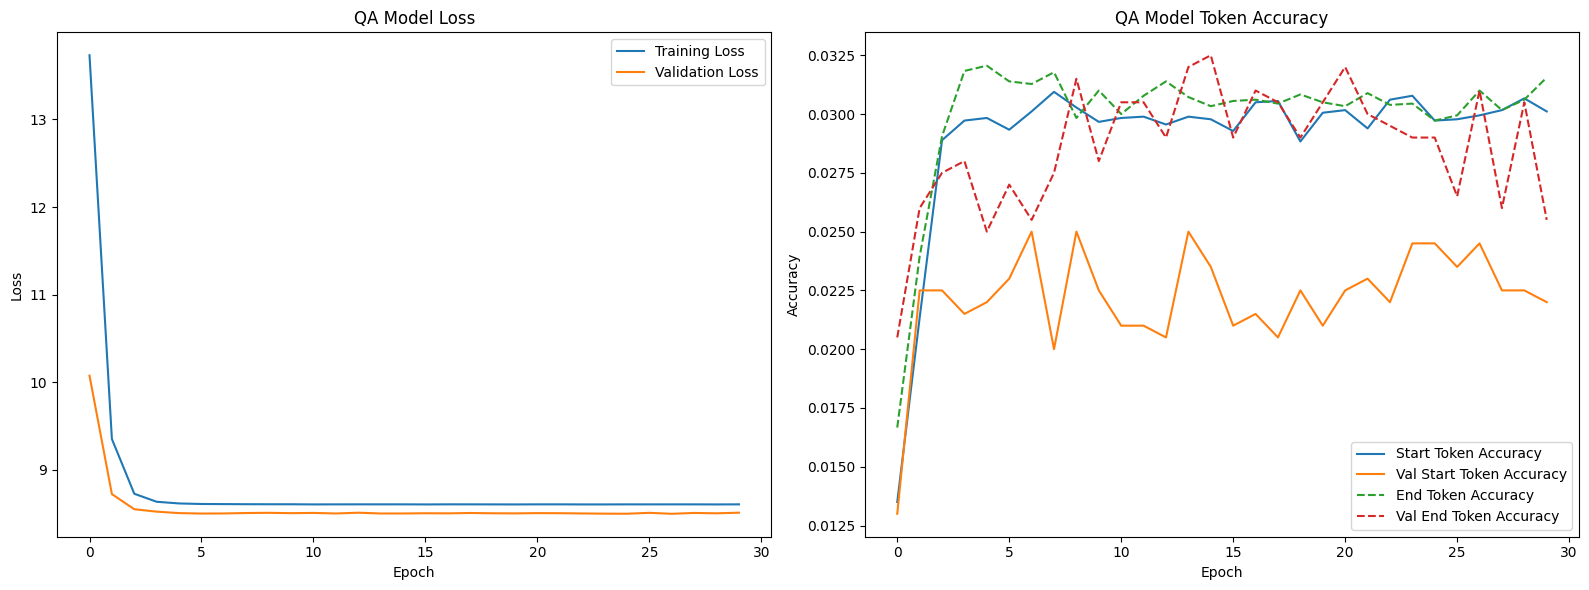

In [45]:
# Plotting the fine-tuning history
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Loss
axes[0].plot(history_qa.history['loss'], label='Training Loss')
axes[0].plot(history_qa.history['val_loss'], label='Validation Loss')
axes[0].set_title('QA Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Plot Accuracy (we have two accuracy metrics, one for start and one for end)
axes[1].plot(history_qa.history['start_probs_accuracy'], label='Start Token Accuracy')
axes[1].plot(history_qa.history['val_start_probs_accuracy'], label='Val Start Token Accuracy')
axes[1].plot(history_qa.history['end_probs_accuracy'], label='End Token Accuracy', linestyle='--')
axes[1].plot(history_qa.history['val_end_probs_accuracy'], label='Val End Token Accuracy', linestyle='--')
axes[1].set_title('QA Model Token Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

### Prediction QA Model

In [48]:
# Select a sample from the validation set for inference
sample = squad_dataset["validation"][11]
context = sample["context"]
question = sample["question"]
true_answer = sample["answers"]["text"][0]

# Preprocess the input
input_text = question + " [SEP] " + context

# The vectorize_layer automatically pads/truncates to the correct length (256)
tokenized_input = vectorize_layer([input_text])

# Predict the start and end token probabilities
start_pred, end_pred = qa_model.predict(tokenized_input)

# Find the most likely start and end tokens
start_index = np.argmax(start_pred[0])
end_index = np.argmax(end_pred[0])

# Decode the tokens between start and end to get the answer
vocab = vectorize_layer.get_vocabulary()

answer_tokens = tokenized_input.numpy()[0][start_index : end_index + 1]
predicted_answer = " ".join([vocab[i] for i in answer_tokens if i > 1])

# Display the results
print("="*50)
print("INFERENCE EXAMPLE")
print("="*50)
print(f"Context: {context}")
print(f"\nQuestion: {question}")
print(f"\nTrue Answer: {true_answer}")
print(f"Predicted Answer: {predicted_answer}")
print("="*50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
INFERENCE EXAMPLE
Context: Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title. The game was played on February 7, 2016, at Levi's Stadium in the San Francisco Bay Area at Santa Clara, California. As this was the 50th Super Bowl, the league emphasized the "golden anniversary" with various gold-themed initiatives, as well as temporarily suspending the tradition of naming each Super Bowl game with Roman numerals (under which the game would have been known as "Super Bowl L"), so that the logo could prominently feature the Arabic numerals 50.

Question: Who won Super Bowl 50?

True Answer: Denver Broncos
Predicted Answer: 


### Comparison

Evaluating 'Our Model'...
Our Model Average EM: 0.0000
Our Model Average F1: 0.0178

Evaluating Public Model (DistilBERT)...


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Fetching 0 files: 0it [00:00, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 0 files: 0it [00:00, ?it/s]

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Public Model Average EM: 0.8340
Public Model Average F1: 0.8600


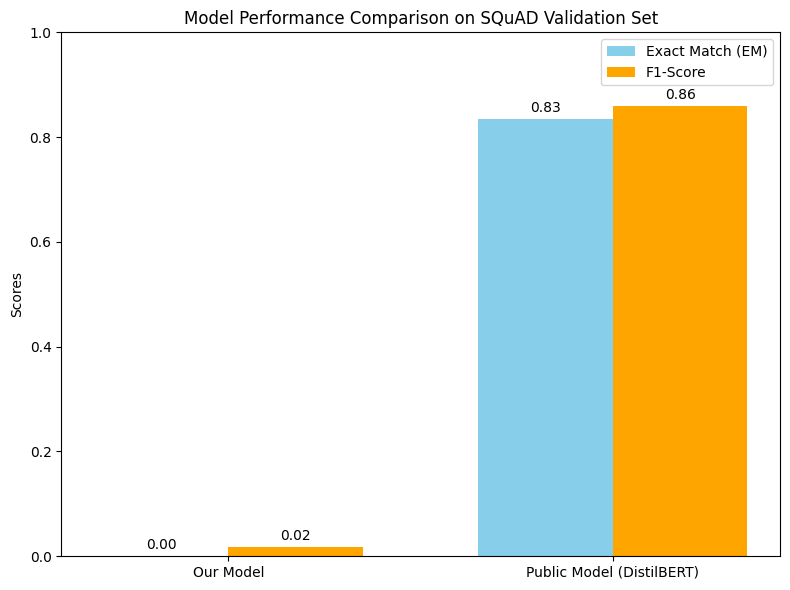

In [ ]:
import collections
import re
import string
from transformers import pipeline

# DEFINE EVALUATION METRICS FOR QUESTION ANSWERING
# These helper functions are the standard way to calculate F1 and Exact Match for SQuAD.
def normalize_answer(s):
    def remove_articles(text):
        return re.sub(r"\b(a|an|the)\b", " ", text)
    def white_space_fix(text):
        return " ".join(text.split())
    def remove_punc(text):
        exclude = set(string.punctuation)
        return "".join(ch for ch in text if ch not in exclude)
    def lower(text):
        return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def f1_score(prediction, ground_truth):
    prediction_tokens = normalize_answer(prediction).split()
    ground_truth_tokens = normalize_answer(ground_truth).split()
    common = collections.Counter(prediction_tokens) & collections.Counter(ground_truth_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0
    precision = 1.0 * num_same / len(prediction_tokens)
    recall = 1.0 * num_same / len(ground_truth_tokens)
    f1 = (2 * precision * recall) / (precision + recall)
    return f1

def exact_match_score(prediction, ground_truth):
    return normalize_answer(prediction) == normalize_answer(ground_truth)

def metric_max_over_ground_truths(metric_fn, prediction, ground_truths):
    scores_for_ground_truths = []
    for ground_truth in ground_truths:
        score = metric_fn(prediction, ground_truth)
        scores_for_ground_truths.append(score)
    return max(scores_for_ground_truths)


# EVALUATE YOUR FINE-TUNED CUSTOM MODEL
print("Evaluating 'Our Model'...")
our_model_em_scores = []
our_model_f1_scores = []

# Use a subset of the validation data for a quicker evaluation
eval_dataset = squad_dataset["validation"].select(range(500))

for example in eval_dataset:
    # Prepare input
    question = example["question"]
    context = example["context"]
    input_text = question + " [SEP] " + context
    tokenized_input = vectorize_layer([input_text])

    # Get prediction
    start_pred, end_pred = qa_model.predict(tokenized_input, verbose=0)
    start_index = np.argmax(start_pred[0])
    end_index = np.argmax(end_pred[0])

    # Decode answer
    vocab = vectorize_layer.get_vocabulary()
    answer_tokens = tokenized_input.numpy()[0][start_index : end_index + 1]
    predicted_answer = " ".join([vocab[i] for i in answer_tokens if i > 1])

    # Get ground truth answers
    ground_truths = example["answers"]["text"]

    # Calculate scores
    em_score = metric_max_over_ground_truths(exact_match_score, predicted_answer, ground_truths)
    f1 = metric_max_over_ground_truths(f1_score, predicted_answer, ground_truths)

    our_model_em_scores.append(em_score)
    our_model_f1_scores.append(f1)

our_model_avg_em = np.mean(our_model_em_scores)
our_model_avg_f1 = np.mean(our_model_f1_scores)

print(f"Our Model Average EM: {our_model_avg_em:.4f}")
print(f"Our Model Average F1: {our_model_avg_f1:.4f}")


# EVALUATE A PUBLIC PRE-TRAINED MODEL
print("\nEvaluating Public Model (DistilBERT)...")
# Load a standard QA model from Hugging Face
public_qa_pipeline = pipeline(
    "question-answering",
    model="distilbert/distilbert-base-cased-distilled-squad",
    device=0
)

public_model_em_scores = []
public_model_f1_scores = []

for example in eval_dataset:
    # Get prediction from the pipeline
    prediction = public_qa_pipeline(question=example["question"], context=example["context"])
    predicted_answer = prediction['answer']

    # Get ground truth answers
    ground_truths = example["answers"]["text"]

    # Calculate scores
    em_score = metric_max_over_ground_truths(exact_match_score, predicted_answer, ground_truths)
    f1 = metric_max_over_ground_truths(f1_score, predicted_answer, ground_truths)

    public_model_em_scores.append(em_score)
    public_model_f1_scores.append(f1)

public_model_avg_em = np.mean(public_model_em_scores)
public_model_avg_f1 = np.mean(public_model_f1_scores)

print(f"Public Model Average EM: {public_model_avg_em:.4f}")
print(f"Public Model Average F1: {public_model_avg_f1:.4f}")


#  VISUAL COMPARISON
labels = ['Our Model', 'Public Model (DistilBERT)']
em_scores = [our_model_avg_em, public_model_avg_em]
f1_scores = [our_model_avg_f1, public_model_avg_f1]

x = np.arange(len(labels)) 
width = 0.35  

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, em_scores, width, label='Exact Match (EM)', color='skyblue')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='orange')

# Add some text for labels, title and axes ticks
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison on SQuAD Validation Set')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1)

# Attach a text label above each bar, displaying its height.
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()